# Exploring error caused by ud/ew decomposition

In [1]:
import xarray as xr
import numpy as np
import rioxarray 
import rasterio as rio
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## set up look vectors for site

In [2]:
# function to rewrite coordinates from metadata
def coord_range(ds):
    latrange = np.linspace(float(ds.attrs['Y_FIRST']),
                           ((float(ds.attrs['Y_STEP'])*float(ds.attrs['LENGTH']))+float(ds.attrs['Y_FIRST'])),
                           int(ds.attrs['LENGTH']))
    lonrange = np.linspace(float(ds.attrs['X_FIRST']),
                           ((float(ds.attrs['X_STEP'])*float(ds.attrs['WIDTH']))+float(ds.attrs['X_FIRST'])),
                           int(ds.attrs['WIDTH']))
    return latrange, lonrange

def mintpy2d_to_xarray(fn, crs):
    ds = xr.open_dataset(fn, engine='h5netcdf', phony_dims='sort')
    ds = ds.rename_dims({'phony_dim_0':'y',
                         'phony_dim_1':'x'
                        })
    latrange, lonrange = coord_range(ds)
    ds = ds.assign_coords({'y': ('y', latrange),
                          'x': ('x', lonrange)})
    ds = ds.rio.write_crs(crs)
    
    return ds

In [3]:
# function to read time series into xarray
def mintpyTS_to_xarray(fn, crs):
    ds = xr.open_dataset(fn, cache=False)
    ds = ds.rename_dims({'phony_dim_1':'time',
                         'phony_dim_2':'y',
                         'phony_dim_3':'x'})
    ds = ds.rename({'timeseries': 'displacement'})
    latrange, lonrange = coord_range(ds)
    ds = ds.assign_coords({'time': ('time', pd.to_datetime(ds.date)),
                           'y': ('y', latrange),
                           'x': ('x', lonrange)})
    ds = ds.drop(['bperp', 'date'])
    ds = ds.rio.write_crs(crs)
    ds['displacement'] = ds['displacement'] * -1
    
    return ds

In [4]:
asc_mintpy_path = '../asc_mintpy_insaronly'
des_mintpy_path = '../des_mintpy_insaronly'

# define crs 
crs = 32645

In [5]:
# read geometry files into xarray ds
asc_geom_fn = f'{asc_mintpy_path}/inputs/geometryGeo.h5'
des_geom_fn = f'{des_mintpy_path}/inputs/geometryGeo.h5'
asc_geom_ds = mintpy2d_to_xarray(asc_geom_fn, crs)
des_geom_ds = mintpy2d_to_xarray(des_geom_fn, crs)

In [6]:
# define azimuth angle from sensor to target relative to north
asc_geom_ds['azimuthAngle'] =  90 - (asc_geom_ds['azimuthAngle'] - 90)
des_geom_ds['azimuthAngle'] = np.abs(des_geom_ds['azimuthAngle'] + 90) + 270

In [7]:
# construct unit look vectors 
asc_geom_ds['n_hat'] = np.cos(np.radians(asc_geom_ds.azimuthAngle))*np.sin(np.radians(asc_geom_ds.incidenceAngle))
asc_geom_ds['e_hat'] = np.sin(np.radians(asc_geom_ds.azimuthAngle))*np.sin(np.radians(asc_geom_ds.incidenceAngle))
asc_geom_ds['z_hat'] = -np.cos(np.radians(asc_geom_ds.incidenceAngle))

des_geom_ds['n_hat'] = np.cos(np.radians(des_geom_ds.azimuthAngle))*np.sin(np.radians(des_geom_ds.incidenceAngle))
des_geom_ds['e_hat'] = np.sin(np.radians(des_geom_ds.azimuthAngle))*np.sin(np.radians(des_geom_ds.incidenceAngle))
des_geom_ds['z_hat'] = -np.cos(np.radians(des_geom_ds.incidenceAngle))

In [8]:
# vertical_unit_vector = np.array([np.zeros_like(des_geom_ds['n_hat'].values), np.zeros_like(des_geom_ds['n_hat'].values), np.ones_like(des_geom_ds['n_hat'].values)])
# horizontal_unit_vector = np.array([np.zeros_like(des_geom_ds['n_hat'].values), np.ones_like(des_geom_ds['n_hat'].values), np.zeros_like(des_geom_ds['n_hat'].values)])

In [8]:
ud_unit_vector = np.array([0, 0, 1])
ew_unit_vector = np.array([0, 1, 0])
ns_unit_vector = np.array([1, 0, 0])

In [9]:
asc_unit_vector = np.array([asc_geom_ds['n_hat'].mean(), asc_geom_ds['e_hat'].mean(), asc_geom_ds['z_hat'].mean()])
des_unit_vector = np.array([des_geom_ds['n_hat'].mean(), des_geom_ds['e_hat'].mean(), des_geom_ds['z_hat'].mean()])
print(asc_unit_vector, des_unit_vector)

[ 0.1085902  0.5753063 -0.8106891] [ 0.11214122 -0.6027571  -0.78999805]


## experiment with theoretical values

In [11]:
# set true displacement values
true_ud = -10
true_ew = 10
true_ns = np.arange(-50, 50)

In [10]:
# Define the unit vector dot products
asc_ew = np.dot(asc_unit_vector, ew_unit_vector)
asc_ud = np.dot(asc_unit_vector, ud_unit_vector)
des_ew = np.dot(des_unit_vector, ew_unit_vector)
des_ud = np.dot(des_unit_vector, ud_unit_vector)
asc_ns = np.dot(asc_unit_vector, ns_unit_vector)
des_ns = np.dot(des_unit_vector, ns_unit_vector)

In [58]:
des_ns

0.11214122176170349

In [13]:
# calculate observed LOS displacements 
d_asc = asc_ns*true_ns + asc_ew*true_ew + asc_ud*true_ud
d_des = des_ns*true_ns + des_ew*true_ew + des_ud*true_ud
#print(d_asc, d_des)

In [14]:
# calculate ud from LOS displacements
estimated_ud = (asc_ew*d_des - des_ew*d_asc)/(asc_ew*des_ud-des_ew*asc_ud)
#print(estimated_ud)

In [15]:
# calculate ew from los displacements
estimated_ew = (asc_ud*estimated_ud - d_asc)/-asc_ew
#print(estimated_ew)

In [16]:
# check that calculated ew and ud explain observed LOS displacements
d_asc_reconstructed = asc_ew*estimated_ew + asc_ud*estimated_ud
d_des_reconstructed = des_ew*estimated_ew + des_ud*estimated_ud

In [17]:
# estimate error
ud_error = ((estimated_ud - true_ud)/np.abs(true_ud))*100
ns_perc_ud = (true_ns/true_ud)*100

ew_error = ((estimated_ew - true_ew)/np.abs(true_ew))*100
ns_perc_ew = (true_ns/true_ew)*100

(-40.0, 40.0)

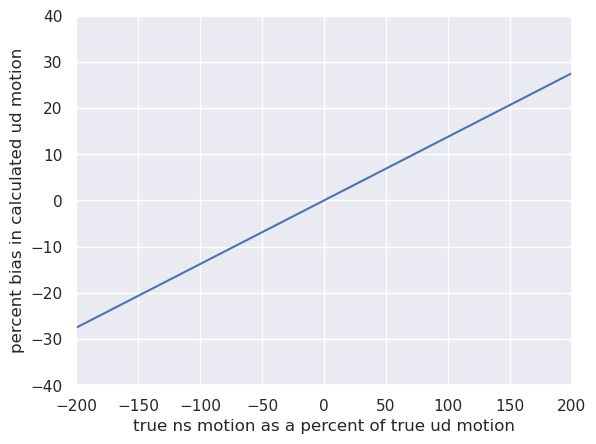

In [18]:
# plot percent bias in ud for different ns displacements
sns.set_theme()
f, ax = plt.subplots()
ax.plot(ns_perc_ud, ud_error)
#ax.plot(ns_perc_ew, ew_error)
ax.set_xlabel("true ns motion as a percent of true ud motion")
ax.set_ylabel("percent bias in calculated ud motion")
ax.set_xlim(-200, 200)
ax.set_ylim(-40, 40)

(-5.0, 5.0)

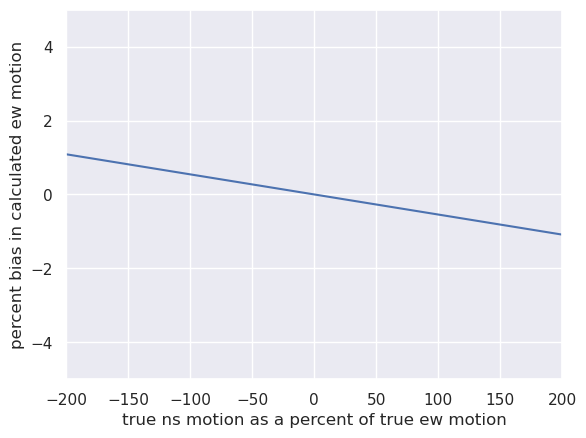

In [19]:
# plot percent bias in ew for different ns displacements
f, ax = plt.subplots()
ax.plot(ns_perc_ew, ew_error)
ax.set_xlabel("true ns motion as a percent of true ew motion")
ax.set_ylabel("percent bias in calculated ew motion")
ax.set_xlim(-200, 200)
ax.set_ylim(-5, 5)

## using real data

In [11]:
# open asc veloc
asc_veloc_fn = '../asc_mean_velocity_imja.tif'
asc_veloc = rioxarray.open_rasterio(asc_veloc_fn).squeeze()

# open des veloc
des_veloc_fn = '../des_mean_velocity_imja.tif'
des_veloc = rioxarray.open_rasterio(des_veloc_fn).squeeze()

In [12]:
d_asc = asc_veloc.values
d_des = des_veloc.values

In [13]:
# recalculate ew and ud from mean asc and des
estimated_ud = (asc_ew*d_des - des_ew*d_asc)/(asc_ew*des_ud-des_ew*asc_ud)
estimated_ew = (asc_ud*estimated_ud - d_asc)/-asc_ew

In [14]:
estimated_ud = xr.DataArray(
    estimated_ud,
    dims=asc_veloc.dims,
    coords=asc_veloc.coords,
    attrs=asc_veloc.attrs
)

estimated_ew = xr.DataArray(
    estimated_ew,
    dims=asc_veloc.dims,
    coords=asc_veloc.coords,
    attrs=asc_veloc.attrs
)

In [15]:
# open ns DEM rate
ns_veloc_fn = 'dem_vy_resampled.tif'
ns_veloc = rioxarray.open_rasterio(ns_veloc_fn).squeeze()
ns_veloc = ns_veloc.rio.reproject_match(asc_veloc, crs = 32645)
true_ns = ns_veloc.values

In [16]:
# Adjusted displacements
d_asc_adjusted = d_asc - asc_ns * true_ns
d_des_adjusted = d_des - des_ns * true_ns

In [17]:
ud_adjusted = (asc_ew*d_des_adjusted - des_ew*d_asc_adjusted)/(asc_ew*des_ud-des_ew*asc_ud)
ew_adjusted = (asc_ud*ud_adjusted - d_asc_adjusted)/-asc_ew

In [18]:
ud_adjusted = xr.DataArray(
    ud_adjusted,
    dims=asc_veloc.dims,
    coords=asc_veloc.coords,
    attrs=asc_veloc.attrs
)

ew_adjusted = xr.DataArray(
    ew_adjusted,
    dims=asc_veloc.dims,
    coords=asc_veloc.coords,
    attrs=asc_veloc.attrs
)

In [19]:
ud_adjusted.rio.to_raster('ud_contstrained_w_dem_ns.tif')
ew_adjusted.rio.to_raster('ew_contstrained_w_dem_ns.tif')

In [20]:
estimated_ud.rio.to_raster('ud_from_mean_los_veloc.tif')
estimated_ew.rio.to_raster('ew_from_mean_los_veloc.tif')

## required ns velocity to create observed summer acceleration

In [156]:
# # open summer velocity
# summer_asc_fn = '../sep_oct_median_asc_velocity.tif'
# summer_asc = rioxarray.open_rasterio(summer_asc_fn).squeeze()

# # open summer velocity
# summer_des_fn = '../sep_oct_median_des_velocity.tif'
# summer_des = rioxarray.open_rasterio(summer_des_fn).squeeze()

In [126]:
# # open winter velocity
# winter_asc_fn = '../jan_feb_median_asc_velocity.tif'
# winter_asc = rioxarray.open_rasterio(winter_asc_fn).squeeze()

# # open winter velocity
# winter_des_fn = '../jan_feb_median_des_velocity.tif'
# winter_des = rioxarray.open_rasterio(winter_des_fn).squeeze()

In [157]:
# open summer velocity
summer_veloc_fn = '../sep_oct_median_vertical_velocity.tif'
summer_veloc = rioxarray.open_rasterio(summer_veloc_fn).squeeze()

In [158]:
# open winter velocity
winter_veloc_fn = '../jan_feb_median_vertical_velocity.tif'
winter_veloc = rioxarray.open_rasterio(winter_veloc_fn).squeeze()

In [159]:
summer_asc = summer_veloc*asc_ud
winter_asc = winter_veloc*asc_ud

In [160]:
asc_diff = summer_asc - winter_asc
# des_diff = summer_des - winter_des

In [166]:
asc_ud

-0.8106890916824341

In [165]:
asc_diff.rio.to_raster('../seasonal_asc_veloc_change.tif')

In [152]:
required_ns_asc = asc_diff/asc_ns
required_ns_des = des_diff/des_ns

required_ud_asc
required_ud_des

In [153]:
required_ns_asc = xr.DataArray(
    required_ns_asc,
    dims=asc_veloc.dims,
    coords=asc_veloc.coords,
    attrs=asc_veloc.attrs
)

required_ns_des = xr.DataArray(
    required_ns_des,
    dims=des_veloc.dims,
    coords=des_veloc.coords,
    attrs=des_veloc.attrs
)

In [154]:
required_ns_moving_asc = required_ns_asc.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)
required_ns_moving_des = required_ns_des.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

In [150]:
asc_diff_moving = asc_diff.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)
des_diff_moving = des_diff.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

In [138]:
asc_diff_moving.mean()

<xarray.DataArray ()> Size: 4B
array(0.04896744, dtype=float32)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [141]:
des_diff_moving.mean()

<xarray.DataArray ()> Size: 8B
array(0.0844714)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

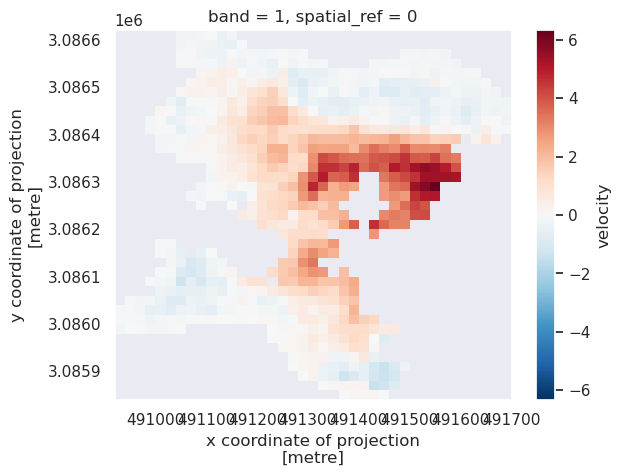

In [155]:
required_ns_moving_des.plot()

In [37]:
required_ns_moving.mean()

<xarray.DataArray ()> Size: 8B
array(0.62186096)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [38]:
required_ns.rio.to_raster('required_ns_for_summer_acceleration.tif')

In [39]:
veloc_diff = xr.DataArray(
    (summer_veloc - winter_veloc),
    dims=asc_veloc.dims,
    coords=asc_veloc.coords,
    attrs=asc_veloc.attrs
)

In [40]:
veloc_diff_moving = veloc_diff.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

In [41]:
veloc_diff_moving.mean()

<xarray.DataArray ()> Size: 8B
array(-0.08329705)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

NameError: name 'true_ns_asc' is not defined

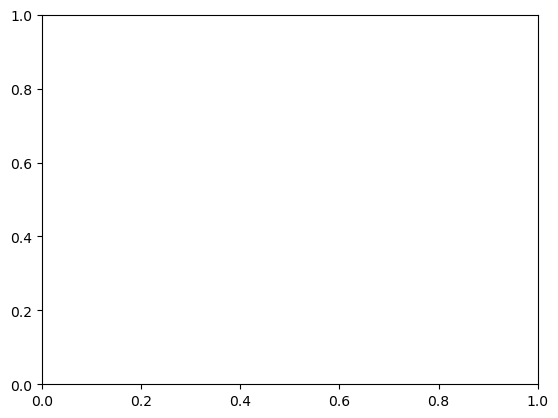

In [42]:
f, ax = plt.subplots()
plt.hist(true_ns_asc.ravel())

## compare calculated and adjusted rates

In [19]:
# set up paths, directories, and variables for this specific dam
dam_name = 'imja'
proc_path = f'/home/jovyan/repos/fufiters_imja_analysis/analysis'

# define crs 
crs = 32645

In [67]:
fufiters_ud = -xr.open_dataset('../vertical_velocity.tif').squeeze().band_data

In [20]:
# read in dam polygon
dam_fn = f'../../mapping/polygons/{dam_name}_md_nocliffs.shp'
dam_gdf = gpd.read_file(dam_fn)
dam_gdf = dam_gdf.to_crs(crs) # reproject in case of mistake

# load in moving area polygon
moving_fn = f'../../mapping/polygons/{dam_name}_moving.shp'
moving_gdf = gpd.read_file(moving_fn)

# load in moving area polygon
reference_fn = f'../../mapping/polygons/{dam_name}_reference.shp'
reference_gdf = gpd.read_file(reference_fn)

# load in stable area polygon
stable_fn = f'../../mapping/polygons/{dam_name}_stable.shp'
stable_gdf = gpd.read_file(stable_fn).to_crs(crs)

# load in water mask
water_fn = f'../../mapping/polygons/water_mask.shp'
water_gdf = gpd.read_file(water_fn).to_crs(crs)

# pad dam bounds by 5 km 
padding = 5000
aoi_extent = [dam_gdf.bounds.minx.item()-padding,
               dam_gdf.bounds.maxy.item()+padding,
               dam_gdf.bounds.maxx.item()+padding,
               dam_gdf.bounds.miny.item()-padding]

In [68]:
ud_moving = fufiters_ud.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)
ud_moving_adjusted = ud_adjusted.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

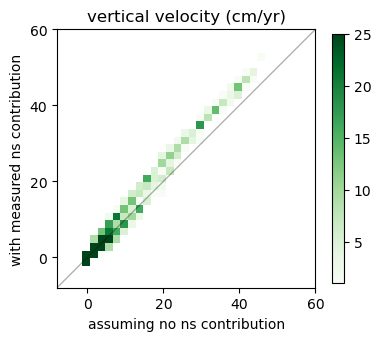

In [35]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.histplot(ax=ax, x=(-ud_moving.values.ravel()*100), y=(-ud_moving_adjusted.values.ravel()*100), 
                 cmap='Greens', cbar=True, alpha=1, binwidth=2, vmin=None, vmax=25, cbar_kws={'shrink':0.7})
ax.plot([-200, 200], [-200, 200], color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.set_title('vertical velocity (cm/yr)')
ax.set_ylabel('with measured ns contribution')
ax.set_xlabel('assuming no ns contribution')
ax.set_box_aspect(1)
ax.set_xlim(-8, 60)
ax.set_ylim(-8, 60)
ax.set_xticks([0, 20,40,60])
ax.set_yticks([0, 20,40,60])
f.tight_layout()

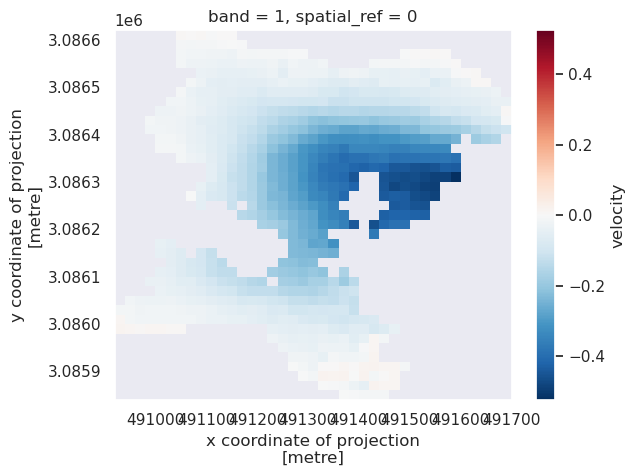

In [56]:
ud_moving_adjusted.plot()

In [69]:
ud_moving_northside = ud_moving.rio.clip([moving_gdf.iloc[0].geometry])
ud_moving_southside = ud_moving.rio.clip([moving_gdf.iloc[1].geometry])

ud_moving_adjusted_northside = ud_moving_adjusted.rio.clip([moving_gdf.iloc[0].geometry])
ud_moving_adjusted_southside = ud_moving_adjusted.rio.clip([moving_gdf.iloc[1].geometry])

In [65]:
ud_moving_adjusted_northside.mean()

<xarray.DataArray ()> Size: 8B
array(-0.16790246)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [71]:
(ud_moving_northside - ud_moving_adjusted_northside).mean()/ud_moving_adjusted_northside.mean()

<xarray.DataArray ()> Size: 8B
array(-0.0973522)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [77]:
ud_moving_adjusted_southside.mean()

<xarray.DataArray ()> Size: 8B
array(-0.05837371)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [80]:
(ud_moving_southside - ud_moving_adjusted_southside).mean()/ud_moving_adjusted_southside.mean()

<xarray.DataArray ()> Size: 8B
array(-0.02052924)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [99]:
(ud_moving - ud_moving_adjusted).mean()/-0.15145219296746737

<xarray.DataArray ()> Size: 8B
array(-0.03840802)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

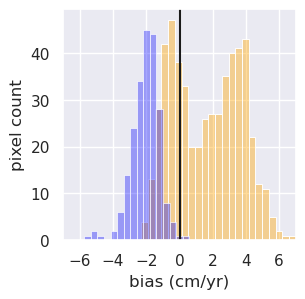

In [86]:
sns.set_theme()

f, ax = plt.subplots(figsize=(3, 3))
sns.histplot((ud_moving_northside - ud_moving_adjusted_northside).values.ravel()*100, ax=ax, binwidth=0.4, color='orange', alpha=0.4)
sns.histplot((ud_moving_southside - ud_moving_adjusted_southside).values.ravel()*100, ax=ax, binwidth=0.4, color='blue', alpha=0.35)
ax.set_xlabel('difference (cm/yr)')
#ax.axvline((ud_moving - ud_moving_adjusted).mean()*100, c='r')
ax.axvline(0, c='k')
ax.set_xlim(-7, 7)
ax.set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax.set_ylabel('pixel count')
ax.set_xlabel('bias (cm/yr)')
plt.savefig('../figs/ud_bias_hist.png', dpi=300, bbox_inches='tight')

In [104]:
difference = ud_moving - ud_moving_adjusted
perc_difference = ((ud_moving - ud_moving_adjusted)/np.abs(ud_moving))*100

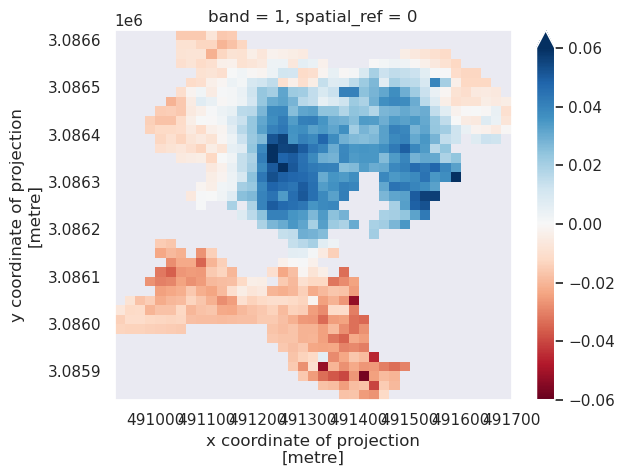

In [105]:
difference.plot(vmin=-0.06, vmax=0.06, cmap='RdBu')

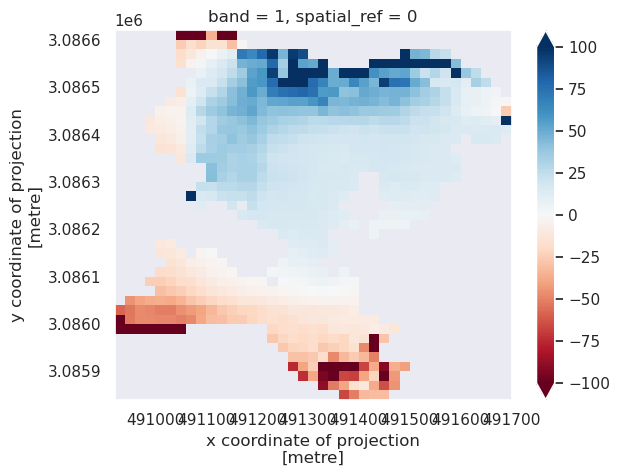

In [59]:
perc_difference.plot(vmax=100, vmin=-100, cmap='RdBu')

## east west

In [88]:
fufiters_ew = xr.open_dataset('../ew_velocity.tif').squeeze().band_data

In [89]:
ew_moving = fufiters_ew.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)
ew_moving_adjusted = ew_adjusted.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs, drop=True)

In [90]:
ew_moving_northside = ew_moving.rio.clip([moving_gdf.iloc[0].geometry])
ew_moving_southside = ew_moving.rio.clip([moving_gdf.iloc[1].geometry])

ew_moving_adjusted_northside = ew_moving_adjusted.rio.clip([moving_gdf.iloc[0].geometry])
ew_moving_adjusted_southside = ew_moving_adjusted.rio.clip([moving_gdf.iloc[1].geometry])

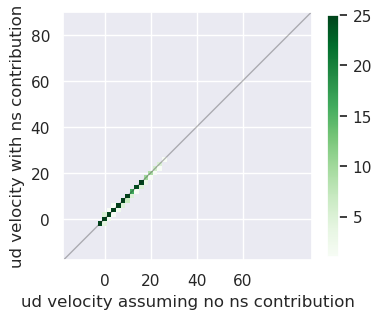

In [42]:
f, ax = plt.subplots(1, 1, figsize=(4, 4))
sns.histplot(ax=ax, x=(ew_moving.values.ravel()*100), y=(ew_moving_adjusted.values.ravel()*100), 
                 cmap='Greens', cbar=True, alpha=1, binwidth=2, vmin=None, vmax=25, cbar_kws={'shrink':0.7})
ax.plot([-200, 200], [-200, 200], color='k', linestyle='-', linewidth=1, alpha=0.3)
ax.set_title('')
ax.set_ylabel('ud velocity with ns contribution')
ax.set_xlabel('ud velocity assuming no ns contribution')
ax.set_box_aspect(1)
ax.set_xlim(-18, 90)
ax.set_ylim(-18, 90)
ax.set_xticks([0, 20,40,60])
f.tight_layout()

In [93]:
(ew_moving_northside - ew_moving_adjusted_northside).mean()

<xarray.DataArray ()> Size: 8B
array(0.00265343)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [100]:
(ew_moving -ew_moving_adjusted).mean()/0.07994626539254053

<xarray.DataArray ()> Size: 8B
array(0.02942819)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [94]:
ew_moving_northside.mean()

<xarray.DataArray 'band_data' ()> Size: 8B
array(0.06131567)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [91]:
(ew_moving_southside - ew_moving_adjusted_southside).mean()/ew_moving_adjusted_southside.mean()

<xarray.DataArray ()> Size: 8B
array(0.08119026)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

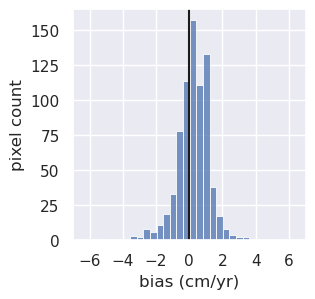

In [108]:
sns.set_theme()

f, ax = plt.subplots(figsize=(3, 3))
sns.histplot((ew_moving - ew_moving_adjusted).values.ravel()*100, ax=ax, binwidth=0.4)
ax.set_xlabel('difference (cm/yr)')
#ax.axvline((ud_moving - ud_moving_adjusted).mean()*100, c='r')
ax.axvline(0, c='k')
ax.set_xlim(-7, 7)
ax.set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax.set_ylabel('pixel count')
ax.set_xlabel('bias (cm/yr)')
plt.savefig('../figs/ew_bias_hist.png', dpi=300, bbox_inches='tight')

In [109]:
difference = ew_moving - ew_moving_adjusted
perc_difference = ((ew_moving - ew_moving_adjusted)/np.abs(ew_moving))*100

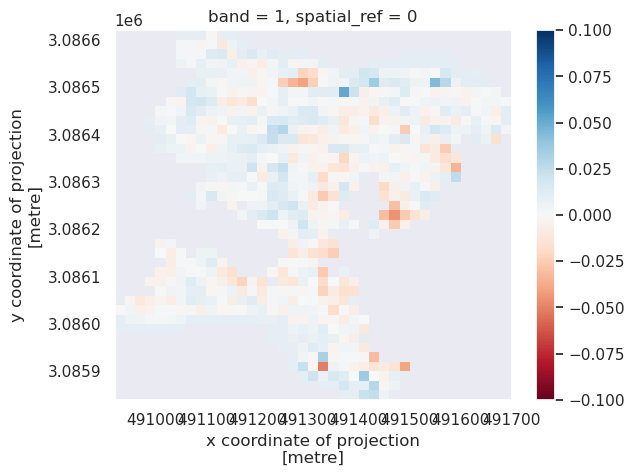

In [110]:
difference.plot(vmin=-0.1, vmax=0.1, cmap='RdBu')

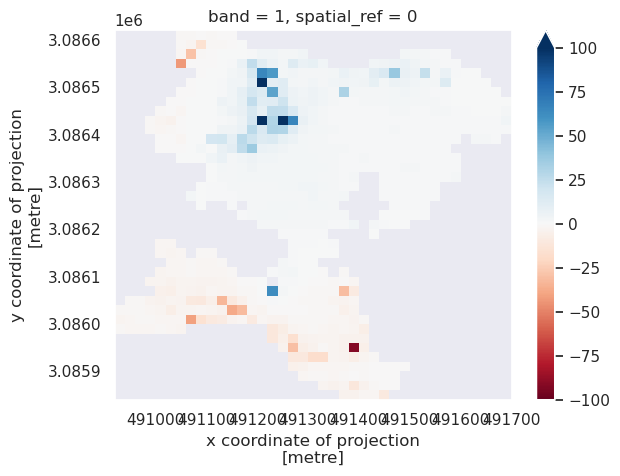

In [46]:
perc_difference.plot(vmax=100, vmin=-100, cmap='RdBu')